# Production predictive modelling

This notebook reports model v2.0. The final holdout was split before comparison; all tuning and threshold selection use development data only.

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import display, Image
ROOT=Path.cwd()
summary=json.loads((ROOT/'outputs/tables/production_model_summary.json').read_text())
display(pd.Series(summary, name='value').to_frame())

,value
model_version,2.0.0
selected_model,Logistic Regression
prediction_moment,"At bedtime, before sleep outcomes occur"
development_rows,750
untouched_holdout_rows,250
positive_prevalence,0.33
majority_baseline_accuracy,0.67
nested_cv,"{'model': 'Logistic Regression', 'accuracy': 0..."
decision_threshold,0.32
false_negative_cost,2


## Prediction timing and leakage controls

The prediction moment is bedtime, before sleep outcomes occur. Sleep duration, latency, wakeups, fatigue, sleep debt, quality score, target, and respondent ID are excluded.

In [2]:
display(pd.DataFrame({'excluded_post_outcome_feature':summary['excluded_post_outcome_features']}))

,excluded_post_outcome_feature
0,daytime_fatigue_score
1,number_of_night_wakeups
2,respondent_id
3,sleep_hours_per_night
4,sleep_latency_minutes
5,sleep_quality_category
6,sleep_quality_score
7,weekly_sleep_debt_hours


## Nested model comparison

Candidates are tuned inside nested cross-validation on the 750-row development partition. Nominal variables use one-hot encoding; no ordinal distances are imposed.

In [3]:
comparison=pd.read_csv(ROOT/'outputs/tables/production_model_comparison.csv')
display(comparison)

,model,accuracy,balanced_accuracy,roc_auc,pr_auc,f1,balanced_accuracy_sd,brier
0,Logistic Regression,0.745333,0.736915,0.794407,0.704483,0.648756,0.040623,0.180950
1,RBF SVM,0.748000,0.734804,0.790697,0.680053,0.646095,0.030517,0.166362
2,Random Forest,0.753333,0.729611,0.795312,0.678332,0.639107,0.029336,0.175396
3,Extra Trees,0.725333,0.725247,0.778260,0.678102,0.636350,0.035043,0.187206


## Calibration, decision policy, and primary-model importance

The threshold is selected from development-only out-of-fold probabilities with false negatives weighted twice as heavily as false positives.

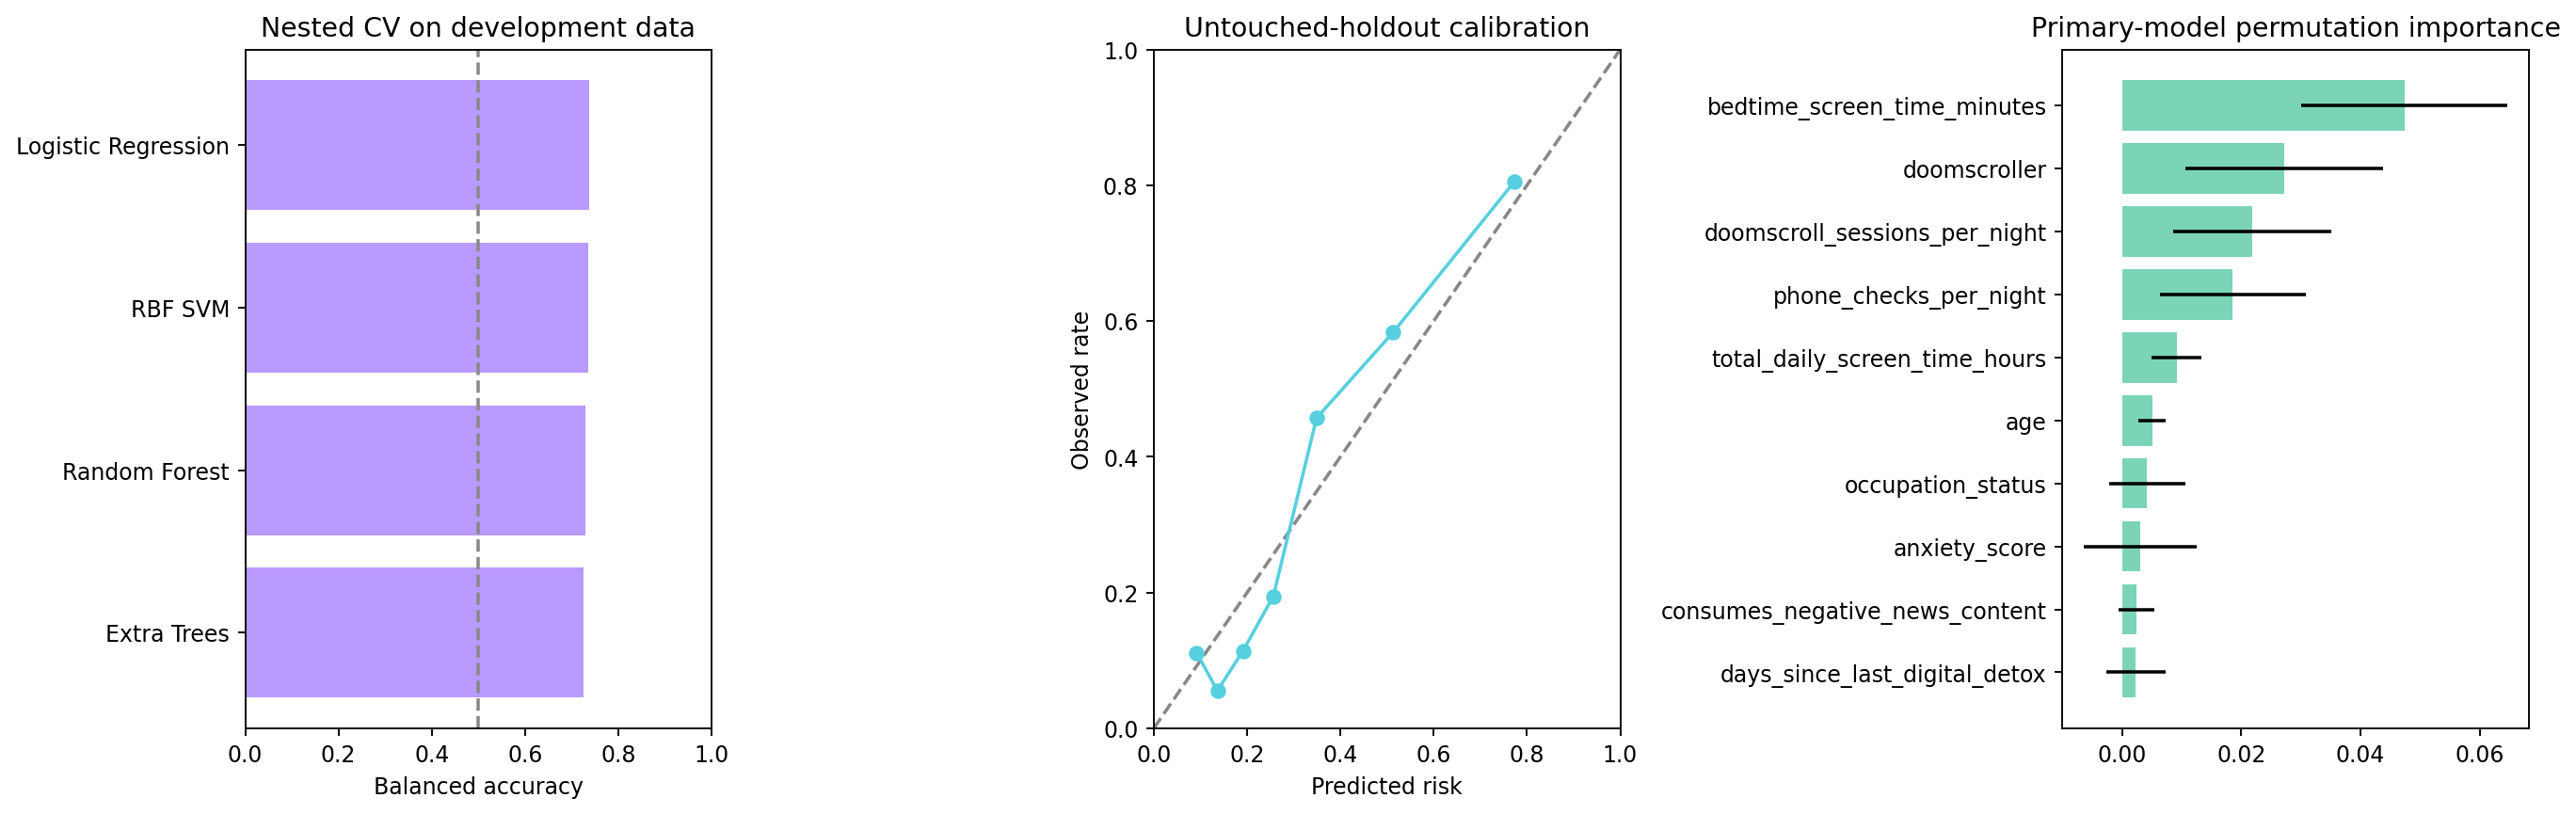

In [4]:
display(Image(filename=str(ROOT/'outputs/figures/15_production_risk_model.png')))

## Untouched holdout and uncertainty

In [5]:
display(pd.Series(summary['holdout'],name='holdout').to_frame())
display(pd.DataFrame(summary['holdout_95_ci']).T)

,holdout
accuracy,0.780000
balanced_accuracy,0.774728
roc_auc,0.824688
pr_auc,0.719959
f1,0.696133
precision,0.642857
sensitivity,0.759036
specificity,0.790419
brier,0.155058
false_negatives,20.000000


,low,high
balanced_accuracy,0.718303,0.827907
roc_auc,0.770193,0.875814
pr_auc,0.615987,0.812989
brier,0.131300,0.179695
sensitivity,0.666667,0.848837
specificity,0.720766,0.850014


## Subgroup diagnostic

These are diagnostics, not fairness certification. Small cells are omitted and all estimates remain uncertain.

In [6]:
display(pd.read_csv(ROOT/'outputs/tables/subgroup_performance.csv'))

,attribute,group,n,accuracy,balanced_accuracy,roc_auc,pr_auc,f1,precision,sensitivity,specificity,brier,false_negatives,false_positives
0,gender,Female,112,0.794643,0.793385,0.835704,0.775782,0.722892,0.666667,0.789474,0.797297,0.141963,8,15
1,gender,Male,122,0.778689,0.776182,0.831016,0.670751,0.689655,0.625000,0.769231,0.783133,0.160096,9,18
2,gender,Prefer not to say,16,0.687500,0.650000,0.733333,0.708466,0.545455,0.600000,0.500000,0.800000,0.208310,3,2
3,age_group,15–19,39,0.769231,0.757143,0.894286,0.778873,0.689655,0.666667,0.714286,0.800000,0.142268,4,5
4,age_group,20–29,102,0.803922,0.784951,0.827714,0.794565,0.729730,0.750000,0.710526,0.859375,0.159173,11,9
5,age_group,30+,109,0.761468,0.784739,0.811001,0.648296,0.666667,0.553191,0.838710,0.730769,0.155785,5,21
6,occupation_status,Employed Full-time,97,0.804124,0.809862,0.861326,0.831444,0.795699,0.740000,0.860465,0.759259,0.156608,6,13
7,occupation_status,Employed Part-time,32,0.812500,0.820513,0.826923,0.628307,0.625000,0.500000,0.833333,0.807692,0.126944,1,5
8,occupation_status,Student,73,0.698630,0.655080,0.732620,0.540781,0.521739,0.500000,0.545455,0.764706,0.181562,10,12
9,occupation_status,Unemployed,39,0.871795,0.837963,0.851852,0.836980,0.782609,0.818182,0.750000,0.925926,0.140384,3,2


## External-validation boundary

No independent real-world validation has been performed. The model must not be treated as clinical, diagnostic, or deployment-ready evidence until the external validation contract is satisfied.